# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
|Sandi Suryo Nugroho|5054251020|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [3]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv('mushrooms.csv')
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
df.head()
df.info()
df.describe()


Jumlah baris : 8124
Jumlah kolom : 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null 

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [4]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.info()
df.isnull().sum()
print("Jumlah '?' pada setiap kolom:")
print((df == '?').sum())
print("Jumlah '?' pada kolom stalk-root:",
      (df["stalk-root"] == "?").sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
df.nunique()
unique_counts = df.nunique().sort_values()

print(unique_counts)

veil-type                    1
class                        2
gill-attachment              2
gill-spacing                 2
stalk-shape                  2
gill-size                    2
bruises                      2
ring-number                  3
stalk-surface-above-ring     4
veil-color                   4
cap-surface                  4
stalk-surface-below-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


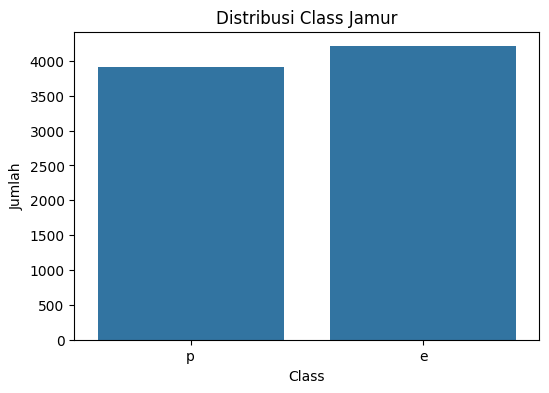

class
e    4208
p    3916
Name: count, dtype: int64
class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


In [6]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="class")

plt.title("Distribusi Class Jamur")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

print(df["class"].value_counts())
print(df["class"].value_counts(normalize=True) * 100)

Distribusi kelas menunjukkan jumlah jamur edible dan poisonous. Perbandingan jumlah kedua kelas digunakan untuk mengetahui apakah dataset mengalami class imbalance. Berdasarkan visualisasi dari box plot, perbandingan jumlah kedua class cukup seimbang

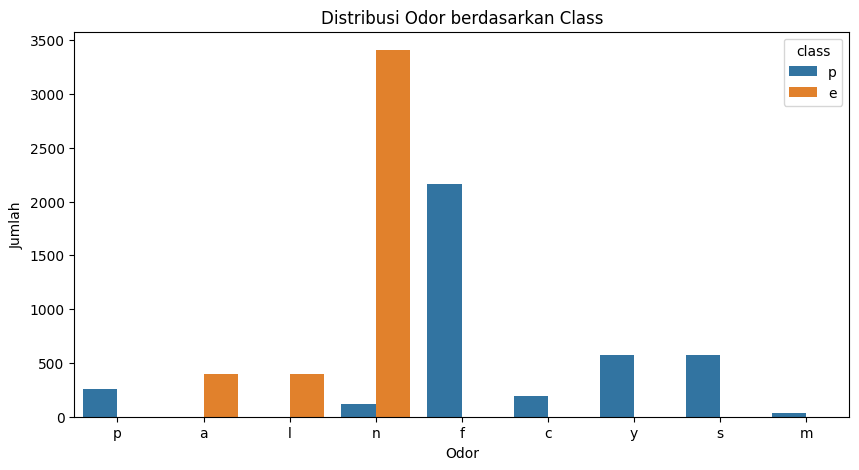

class           e           p
odor                         
a      100.000000    0.000000
c        0.000000  100.000000
f        0.000000  100.000000
l      100.000000    0.000000
m        0.000000  100.000000
n       96.598639    3.401361
p        0.000000  100.000000
s        0.000000  100.000000
y        0.000000  100.000000


In [7]:
#Distribusi fitur odor berdasarkan class target (class) dalam bentuk bar plot.

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="odor",
    hue="class"
)

plt.title("Distribusi Odor berdasarkan Class")
plt.xlabel("Odor")
plt.ylabel("Jumlah")
plt.show()

odor_class = pd.crosstab(
    df["odor"],
    df["class"],
    normalize="index"
) * 100

print(odor_class)

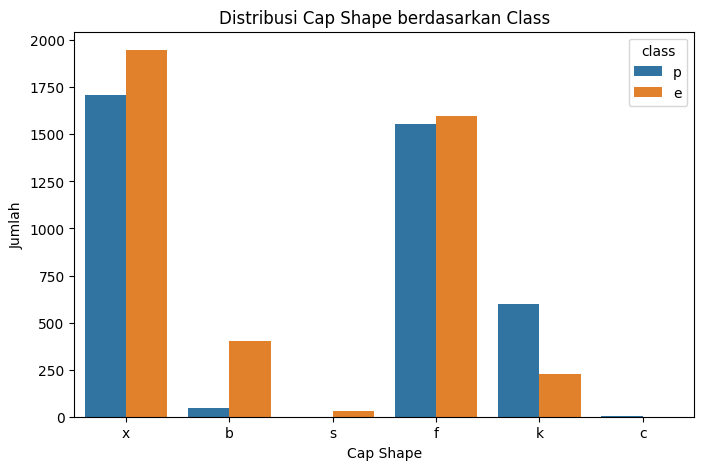

In [8]:
#Distribusi fitur cap-shape berdasarkan class target (class) dalam bentuk bar plot.
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="cap-shape",
    hue="class"
)

plt.title("Distribusi Cap Shape berdasarkan Class")
plt.xlabel("Cap Shape")
plt.ylabel("Jumlah")
plt.show()

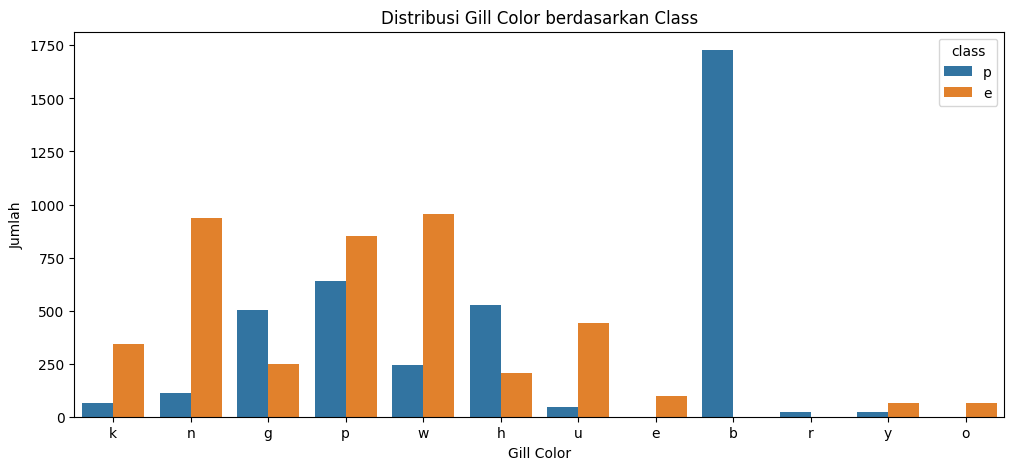

In [9]:
#Distribusi fitur gill-color berdasarkan class target (class) dalam bentuk bar plot.
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="gill-color",
    hue="class"
)

plt.title("Distribusi Gill Color berdasarkan Class")
plt.xlabel("Gill Color")
plt.ylabel("Jumlah")
plt.show()

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [ ]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

df["stalk-root"] = df["stalk-root"].replace("?", "unknown")

print("Jumlah kategori pada stalk-root:")
print(df["stalk-root"].value_counts())

print("\nJumlah missing value:")
print(df.isnull().sum().sum())

Jumlah kategori pada stalk-root:
stalk-root
b          3776
unknown    2480
e          1120
c           556
r           192
Name: count, dtype: int64

Jumlah missing value:
0


In [ ]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

unique_counts = df.nunique()

print("Jumlah nilai unik setiap kolom:")
print(unique_counts)

constant_features = unique_counts[unique_counts == 1].index.tolist()

print("\nFitur dengan hanya satu nilai unik:")
print(constant_features)

df = df.drop(columns=constant_features)

print("\nShape dataset setelah menghapus fitur konstan:")
print(df.shape)

Jumlah nilai unik setiap kolom:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

Fitur dengan hanya satu nilai unik:
['veil-type']

Shape dataset setelah menghapus fitur konstan:
(8124, 22)


In [ ]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.


X = df.drop(columns=["class"])
y = df["class"]


y = y.map({"e": 0, "p": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

print("\nDistribusi class pada training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribusi class pada testing set:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (6499, 21)
Ukuran X_test : (1625, 21)
Ukuran y_train: (6499,)
Ukuran y_test : (1625,)

Distribusi class pada training set:
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Distribusi class pada testing set:
class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


In [ ]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_cat = ordinal_encoder.fit_transform(X_train)
X_test_cat = ordinal_encoder.transform(X_test)

print("Shape X_train setelah OrdinalEncoder:", X_train_cat.shape)
print("Shape X_test setelah OrdinalEncoder :", X_test_cat.shape)

print("\nContoh hasil encoding:")
print(X_train_cat[:5])

Shape X_train setelah OrdinalEncoder: (6499, 21)
Shape X_test setelah OrdinalEncoder : (1625, 21)

Contoh hasil encoding:
[[ 2.  3.  9.  0.  2.  1.  0.  0.  2.  0.  0.  1.  1.  6.  0.  2.  1.  2.
   1.  5.  1.]
 [ 5.  2.  5.  1.  5.  1.  0.  0.  1.  0.  4.  2.  2.  2.  7.  2.  2.  0.
   7.  1.  6.]
 [ 0.  2.  3.  0.  5.  1.  1.  0. 10.  0.  4.  1.  2.  7.  7.  2.  2.  4.
   7.  3.  1.]
 [ 2.  2.  4.  0.  7.  1.  0.  1.  0.  1.  4.  1.  1.  6.  7.  2.  1.  0.
   7.  4.  0.]
 [ 3.  3.  4.  0.  2.  1.  0.  1.  0.  1.  4.  2.  1.  6.  6.  2.  1.  0.
   7.  4.  4.]]


In [ ]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

X_train_onehot = onehot_encoder.fit_transform(X_train)
X_test_onehot = onehot_encoder.transform(X_test)

print("Shape X_train setelah OneHotEncoder:", X_train_onehot.shape)
print("Shape X_test setelah OneHotEncoder :", X_test_onehot.shape)

Shape X_train setelah OneHotEncoder: (6499, 116)
Shape X_test setelah OneHotEncoder : (1625, 116)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [25]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

categorical_nb = CategoricalNB()
categorical_nb.fit(X_train_cat, y_train)

print("CategoricalNB berhasil dilatih.")

CategoricalNB berhasil dilatih.


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_cat = categorical_nb.predict(X_test_cat)
y_prob_cat = categorical_nb.predict_proba(X_test_cat)[:, 1]

print("Contoh hasil prediksi:")
print(y_pred_cat[:10])

print("\nContoh probabilitas class 1:")
print(y_prob_cat[:10])

Contoh hasil prediksi:
[1 0 0 1 1 0 0 0 0 0]

Contoh probabilitas class 1:
[1.00000000e+00 3.69231318e-01 1.69422230e-06 1.00000000e+00
 1.00000000e+00 2.32133395e-07 2.39370910e-08 4.33080758e-07
 7.46792155e-06 2.02738864e-01]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [ ]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bernoulli_nb = BernoulliNB()

bernoulli_nb.fit(X_train_onehot, y_train)

print("BernoulliNB berhasil dilatih.")

BernoulliNB berhasil dilatih.


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_ber = bernoulli_nb.predict(X_test_onehot)
y_prob_ber = bernoulli_nb.predict_proba(X_test_onehot)[:, 1]

print("Contoh hasil prediksi:")
print(y_pred_ber[:10])

print("\nContoh probabilitas class 1:")
print(y_prob_ber[:10])

Contoh hasil prediksi:
[1 0 0 1 1 0 0 0 0 0]

Contoh probabilitas class 1:
[1.00000000e+00 4.06871535e-01 2.58243564e-09 1.00000000e+00
 1.00000000e+00 4.14263609e-09 7.49221190e-10 9.27108223e-09
 2.09551000e-08 6.80420491e-02]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train_onehot, y_train)

print("MultinomialNB berhasil dilatih.")

MultinomialNB berhasil dilatih.


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_multi = multinomial_nb.predict(X_test_onehot)
y_prob_multi = multinomial_nb.predict_proba(X_test_onehot)[:, 1]

print("Contoh hasil prediksi:")
print(y_pred_multi[:10])

print("\nContoh probabilitas class 1:")
print(y_prob_multi[:10])

Contoh hasil prediksi:
[1 0 0 1 1 0 0 0 0 0]

Contoh probabilitas class 1:
[1.00000000e+00 3.69231017e-01 1.69422011e-06 1.00000000e+00
 1.00000000e+00 2.32133095e-07 2.39370600e-08 4.33080197e-07
 7.46791188e-06 2.02738655e-01]


# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

results = pd.DataFrame({
    "Model": [
        "Categorical NB",
        "Bernoulli NB",
        "Multinomial NB"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_cat),
        accuracy_score(y_test, y_pred_ber),
        accuracy_score(y_test, y_pred_multi)
    ],
    "Precision": [
        precision_score(y_test, y_pred_cat),
        precision_score(y_test, y_pred_ber),
        precision_score(y_test, y_pred_multi)
    ],
    "Recall": [
        recall_score(y_test, y_pred_cat),
        recall_score(y_test, y_pred_ber),
        recall_score(y_test, y_pred_multi)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_cat),
        f1_score(y_test, y_pred_ber),
        f1_score(y_test, y_pred_multi)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


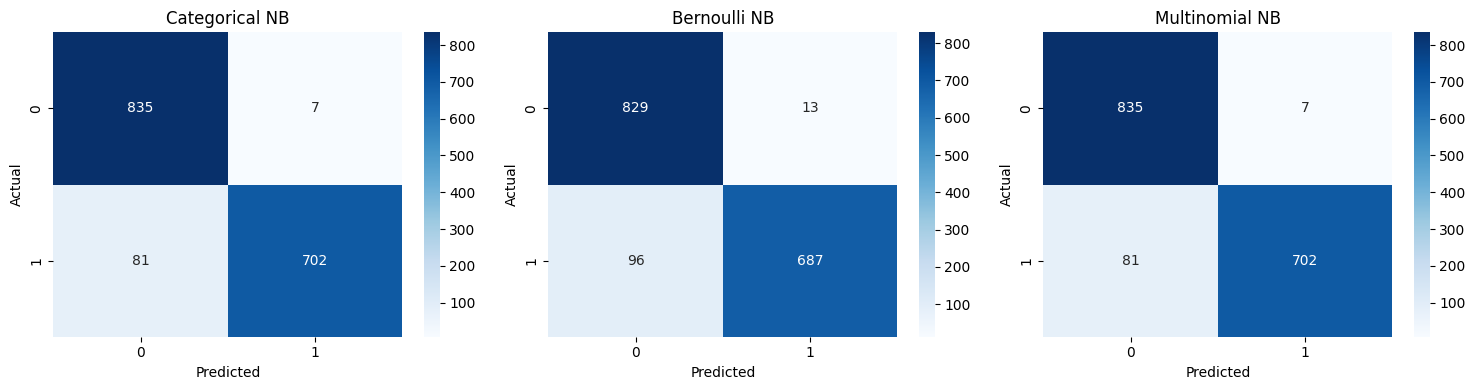

In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

cm_cat = confusion_matrix(y_test, y_pred_cat)
cm_ber = confusion_matrix(y_test, y_pred_ber)
cm_multi = confusion_matrix(y_test, y_pred_multi)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(
    cm_cat,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Categorical NB")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_ber,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Bernoulli NB")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2]
)
axes[2].set_title("Multinomial NB")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

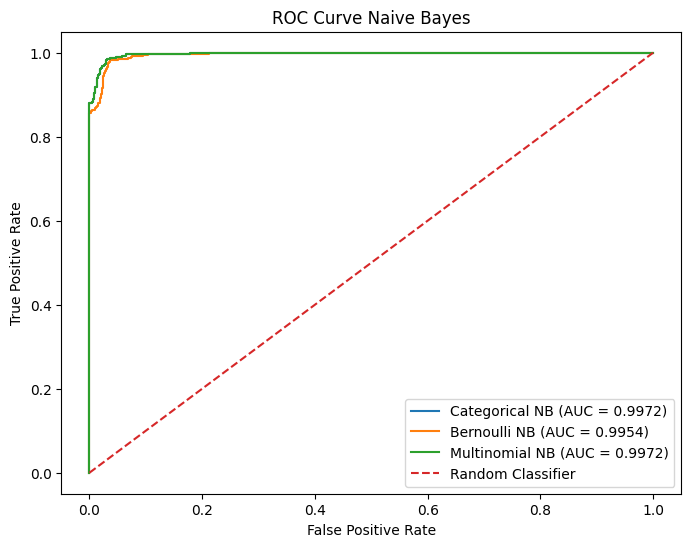

AUC Categorical NB : 0.9971848332893464
AUC Bernoulli NB   : 0.9954283876800053
AUC Multinomial NB : 0.9971848332893464


In [ ]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
fpr_ber, tpr_ber, _ = roc_curve(y_test, y_prob_ber)
fpr_multi, tpr_multi, _ = roc_curve(y_test, y_prob_multi)

auc_cat = roc_auc_score(y_test, y_prob_cat)
auc_ber = roc_auc_score(y_test, y_prob_ber)
auc_multi = roc_auc_score(y_test, y_prob_multi)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_cat,
    tpr_cat,
    label=f"Categorical NB (AUC = {auc_cat:.4f})"
)

plt.plot(
    fpr_ber,
    tpr_ber,
    label=f"Bernoulli NB (AUC = {auc_ber:.4f})"
)

plt.plot(
    fpr_multi,
    tpr_multi,
    label=f"Multinomial NB (AUC = {auc_multi:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Naive Bayes")
plt.legend()
plt.show()

print("AUC Categorical NB :", auc_cat)
print("AUC Bernoulli NB   :", auc_ber)
print("AUC Multinomial NB :", auc_multi)

# 5. Analisis




Categorical Naive Bayes (NB) dan Multinomial NB memberikan performa terbaik dan identik dengan **Accuracy 94,58%**, **Precision 99,01%**, **Recall 89,66%**, dan **F1-Score 94,10%**. Bernoulli NB sedikit di bawahnya dengan Accuracy 93,29% dan F1-Score 92,65%.

| Model | TN | FP | FN | TP |
| --- | --- | --- | --- | --- |
| **Categorical NB & Multinomial NB** | 835 | 7 | **81** | 702 |
| **Bernoulli NB** | 829 | 13 | **96** | 687 |

**Temuan Utama & Kesimpulan:**

* **Model Terbaik:** Categorical NB sangat cocok karena karakteristik asli dataset berbentuk kategorikal, sedangkan Multinomial NB mencapai performa sama setelah diterapkan One-Hot Encoding.
* **Evaluasi Keamanan:** Precision yang tinggi menunjukkan model sangat akurat saat memprediksi jamur beracun (poisonous). Namun, adanya **False Negative** (81 jamur beracun terprediksi sebagai edible pada model terbaik) menjadi catatan krusial yang paling berisiko dalam konteks klasifikasi keamanan jamur.


# 6. Kesimpulan dan Saran

Ketiga model Naive Bayes menunjukkan performa tinggi dalam mengklasifikasikan jamur edible dan poisonous. **Categorical NB** dan **Multinomial NB** menjadi model terbaik yang identik dengan **Accuracy 94,58%** dan **F1-Score 94,10%**, unggul atas Bernoulli NB (Accuracy 93,29% dan F1-Score 92,65%) yang menghasilkan lebih banyak kesalahan *False Negative*.

**Poin Penting untuk Implementasi:**

* **Model Terbaik:** Categorical NB dan Multinomial NB paling direkomendasikan untuk dataset ini.
* **Catatan Kritis:** Masih terdapat **81 jamur beracun (*poisonous*) yang terprediksi sebagai jamur aman (*edible*)**. Dalam penerapan dunia nyata, angka *False Negative* ini harus terus ditekan melalui peningkatan nilai *recall* demi mencegah risiko fatal konsumsi jamur beracun.